In [5]:
import craigslistscraper as cs
# Define the search. Everything is done lazily, and so the html is not 
# fetched at this step.
search = cs.Search(
    query = "bmw e46",
    city = "sfbay",
    category = "cto"
)
status = search.fetch()
if status != 200:
    raise Exception(f"Unable to fetch search with status <{status}>.")

In [6]:
ex = search.ads[0]

In [7]:
status = ex.fetch()
if status != 200:
    print(f"Unable to fetch ad '{ex.title}' with status <{status}>.")

# Example: representing a vehicle listing with the Listing class

In [10]:
from pathlib import Path
import os 
from VehicleVision.listing import Listing
import joblib
import pandas as pd

In [11]:

parent_folder = Path(os.path.join(os.getcwd(), Path("images")))
listing_ex = Listing.from_cs(ex, images_main_path = parent_folder, download_images_bool=True)

✓ Saved: f:\car-project\images\img\7864311634\00q0q_bg9dZbkxN7k_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00p0p_aYXj3glLuN2_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00W0W_ekmV8ozBolH_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\01616_ckoncbo2tVy_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00q0q_c5GsQFYvs6s_0x20oM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\01717_h1YQto1fuPU_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00N0N_7KYNJUjKr2Y_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00U0U_aj9JrejrCq3_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00h0h_gJ2oQZIswSX_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00N0N_cLlaQ9Vv6NQ_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00u0u_f5pBx5bpQID_0gw0co_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864311634\00101_i0mMFIijLvp_0gw0co_1200x

In [ ]:
# 
# with open(Path(os.path.join(os.getcwd(), "cls_ex.joblib")), "wb") as f:
#     joblib.dump(listing_ex,f)

In [2]:
with open(Path(os.path.join(os.getcwd(), "cls_ex.joblib")), "rb") as f:
    listing_ex = joblib.load(f)

In [3]:
listing_ex.to_dict()

{'uid': 7864009461,
 'price': 10995.0,
 'url': 'https://sfbay.craigslist.org/eby/cto/d/clayton-2004-bmw-330-ci-e46/7864009461.html',
 'title': '2004 BMW 330 CI - E46',
 'description': '\n\n\n\n\nUp for sale is a 2004 BMW 3 Series 330Cic Convertible 2D in very good condition. This white beauty with a tan interior has 110,000 miles on the odometer. Key features include:\n\n 6-Cylinder 3.0 Liter engine\n Automatic transmission\n Rear-wheel drive\n ABS and stability control\n Harman Kardon sound system\n Navigation system\n Leather seats with dual power adjustment\n Alloy wheels\n\nPerfect for cruising with the top down on sunny days. The combination of luxury and performance makes this BMW a joy to drive. Interested? Feel free to chat me with any questions about this classic convertible.  I am the third owner and the car has been well looked after.  Just had it serviced at 110 k.  It gets a lot of attention and compliments.  A great find for BMW enthusiasts. \n\nAsking $10,995 OBO\n    ',

# CLIP Example

In [5]:
from PIL import Image
import pandas as pd
from VehicleVision.image.image import CLIPImageProcessor

In [46]:
img = Image.open(listing_ex.image_locs[0])
img_path = listing_ex.image_locs[0]

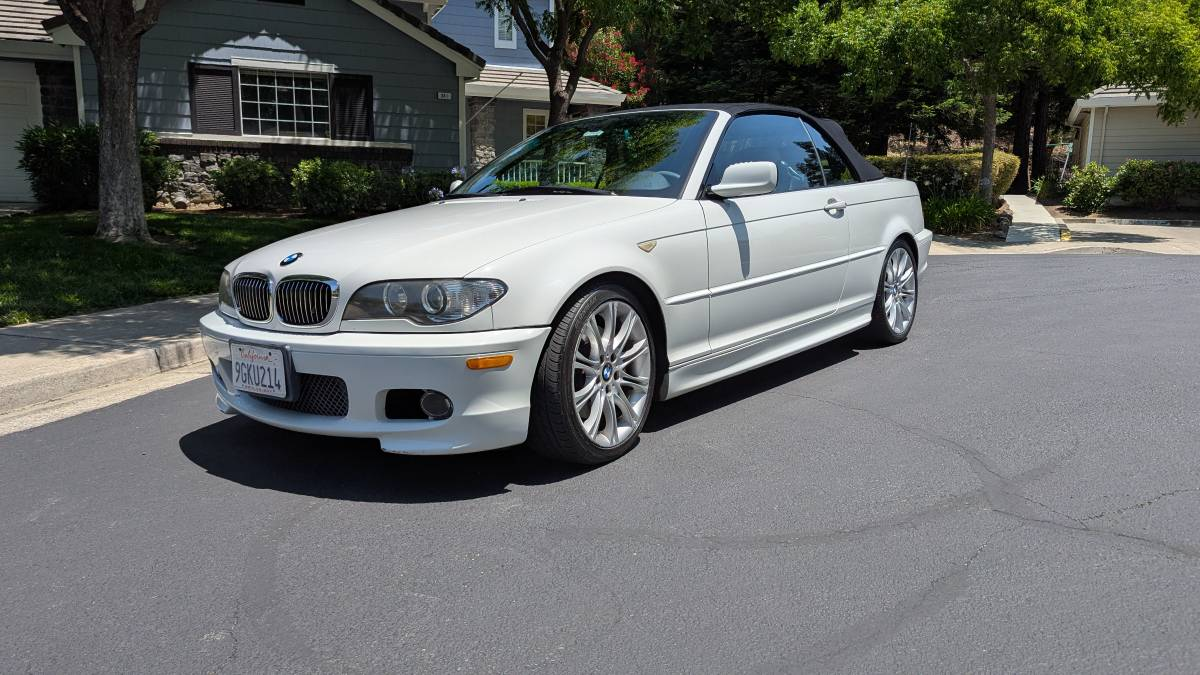

In [40]:
display(img)

In [45]:
img_processor = CLIPImageProcessor(
    clip_model_name= None,
)

In [47]:
probs, cond_probs = img_processor.process_image(img_path)

In [48]:
probs

array([[3.773e-03, 6.390e-05, 1.630e-01, 6.055e-01, 1.818e-01, 4.596e-02,
        2.462e-05, 1.157e-04, 1.533e-04]], dtype=float16)

In [49]:
cond_probs

array([[0.05844 , 0.01573 , 0.03278 , 0.012634, 0.2384  , 0.311   ,
        0.331   ]], dtype=float16)

In [52]:
from VehicleVision.image.constants import Constants
pd.DataFrame({"cls_prompt": Constants.CLASS_PROMPTS, "probs": probs[0]})

f:\car-project\.venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,cls_prompt,probs
0,an SUV,0.003773
1,a bike,0.000064
2,a convertible,0.162964
3,a sedan,0.605469
4,a coupe,0.181763
5,a hatchback,0.045959
6,a diagram,0.000025
7,a dog,0.000116
8,a cat,0.000153


In [53]:
from VehicleVision.image.constants import Constants
pd.DataFrame({"cond_prompt": Constants.CONDITION_PROMPTS, "probs": cond_probs[0]})

f:\car-project\.venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,cond_prompt,probs
0,a car with damaged window,0.058441
1,a car with damaged door,0.015732
2,a car with damaged bumper,0.032776
3,fender bender,0.012634
4,a car with damaged hood,0.238403
5,a car in excellent condition,0.311035
6,a car in average condition,0.331055


## Batch Process them

In [13]:
from VehicleVision.image.image import CLIPImageProcessor
listing_ex.process_images()

In [14]:
listing_ex.image_locs

['f:\\car-project\\images\\img\\7864311634\\00q0q_bg9dZbkxN7k_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00p0p_aYXj3glLuN2_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00W0W_ekmV8ozBolH_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\01616_ckoncbo2tVy_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00q0q_c5GsQFYvs6s_0x20oM_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\01717_h1YQto1fuPU_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00N0N_7KYNJUjKr2Y_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00U0U_aj9JrejrCq3_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00h0h_gJ2oQZIswSX_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00N0N_cLlaQ9Vv6NQ_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00u0u_f5pBx5bpQID_0gw0co_1200x900.jpg',
 'f:\\car-project\\images\\img\\7864311634\\00101_i0mMFIijLvp_0gw0co_1200x90

In [15]:
listing_ex.clip_cond_probs

array([[8.0627e-02, 9.6283e-03, 2.3468e-02, 5.7190e-02, 1.9043e-01,
        3.0444e-01, 3.3423e-01],
       [6.7932e-02, 5.3772e-02, 4.3011e-04, 1.7381e-04, 1.0582e-02,
        7.4219e-01, 1.2500e-01],
       [3.7022e-03, 2.8839e-03, 8.3466e-03, 7.3624e-03, 3.0835e-01,
        1.3684e-01, 5.3271e-01],
       [6.6101e-02, 2.7985e-02, 2.9800e-02, 1.5369e-01, 1.3147e-01,
        2.6562e-01, 3.2544e-01],
       [8.5876e-02, 2.0721e-02, 4.0558e-02, 2.2400e-02, 1.5076e-01,
        4.4995e-01, 2.2986e-01],
       [7.4646e-02, 1.1269e-02, 4.1229e-02, 1.0925e-02, 2.2290e-01,
        2.1606e-01, 4.2310e-01],
       [8.1329e-03, 5.1727e-03, 1.4820e-03, 1.2604e-02, 4.9362e-03,
        1.8811e-01, 7.7979e-01],
       [2.4014e-03, 1.3397e-02, 7.3145e-01, 3.6407e-02, 2.5421e-02,
        3.5278e-02, 1.5576e-01],
       [1.7715e-02, 2.4738e-03, 9.0027e-02, 1.0101e-02, 1.0358e-01,
        4.5703e-01, 3.1909e-01],
       [2.0190e-01, 5.9692e-02, 4.2152e-04, 3.2830e-04, 1.6830e-02,
        4.9194e-01, 2.2

In [6]:
listing_ex.to_dict()

{'uid': 7864009461,
 'price': 10995.0,
 'url': 'https://sfbay.craigslist.org/eby/cto/d/clayton-2004-bmw-330-ci-e46/7864009461.html',
 'title': '2004 BMW 330 CI - E46',
 'description': '\n\n\n\n\nUp for sale is a 2004 BMW 3 Series 330Cic Convertible 2D in very good condition. This white beauty with a tan interior has 110,000 miles on the odometer. Key features include:\n\n 6-Cylinder 3.0 Liter engine\n Automatic transmission\n Rear-wheel drive\n ABS and stability control\n Harman Kardon sound system\n Navigation system\n Leather seats with dual power adjustment\n Alloy wheels\n\nPerfect for cruising with the top down on sunny days. The combination of luxury and performance makes this BMW a joy to drive. Interested? Feel free to chat me with any questions about this classic convertible.  I am the third owner and the car has been well looked after.  Just had it serviced at 110 k.  It gets a lot of attention and compliments.  A great find for BMW enthusiasts. \n\nAsking $10,995 OBO\n    ',

In [16]:
# example: how to use the extracted probabilities
clip_probs_df = pd.DataFrame(listing_ex.clip_probs)
clip_probs_df.columns = listing_ex.clip_class_prompts
clip_probs_df.index = listing_ex.image_locs
clip_probs_df

f:\car-project\.venv\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,an SUV,a bike,a convertible,a sedan,a coupe,a hatchback,a diagram,a dog,a cat
f:\car-project\images\img\7864311634\00q0q_bg9dZbkxN7k_0gw0co_1200x900.jpg,0.002499,0.000236,0.024857,0.772949,0.167236,0.031921,0.000033,0.000112,0.000065
f:\car-project\images\img\7864311634\00p0p_aYXj3glLuN2_0gw0co_1200x900.jpg,0.186646,0.000920,0.192505,0.395020,0.021271,0.201782,0.001144,0.000434,0.000318
f:\car-project\images\img\7864311634\00W0W_ekmV8ozBolH_0gw0co_1200x900.jpg,0.038086,0.000645,0.184570,0.486328,0.032562,0.252197,0.004208,0.000587,0.000854
f:\car-project\images\img\7864311634\01616_ckoncbo2tVy_0gw0co_1200x900.jpg,0.009766,0.000281,0.024170,0.576660,0.344238,0.044464,0.000107,0.000241,0.000107
f:\car-project\images\img\7864311634\00q0q_c5GsQFYvs6s_0x20oM_1200x900.jpg,0.001314,0.000065,0.177612,0.505859,0.302002,0.013062,0.000029,0.000043,0.000047
f:\car-project\images\img\7864311634\01717_h1YQto1fuPU_0gw0co_1200x900.jpg,0.006485,0.000218,0.077759,0.849121,0.042938,0.022980,0.000029,0.000155,0.000199
f:\car-project\images\img\7864311634\00N0N_7KYNJUjKr2Y_0gw0co_1200x900.jpg,0.203003,0.048950,0.112061,0.244751,0.240967,0.125000,0.024231,0.000346,0.000597
f:\car-project\images\img\7864311634\00U0U_aj9JrejrCq3_0gw0co_1200x900.jpg,0.565918,0.007469,0.031433,0.255127,0.052643,0.076599,0.008202,0.001278,0.001060
f:\car-project\images\img\7864311634\00h0h_gJ2oQZIswSX_0gw0co_1200x900.jpg,0.014900,0.000560,0.079285,0.764160,0.095642,0.043793,0.000135,0.000379,0.000895
f:\car-project\images\img\7864311634\00N0N_cLlaQ9Vv6NQ_0gw0co_1200x900.jpg,0.260986,0.000220,0.203247,0.300293,0.028366,0.206421,0.000352,0.000089,0.000140


# LLM integration - use LLM to parse descriptions

In [17]:
listing_ex.description

'\n\n\n\n\nSelling my 2005 BMW M3 Coupe (ZCP Competition Package) after 6.5 years of ownership and 40k trouble-free miles. This is a proper driver’s car: 6-speed manual, ZCP package with cloth interior, and tastefully upgraded with high-end components including Ohlins Road & Track suspension and Dinan intake and exhaust. Subframe has been reinforced, the cooling system overhauled, and a host of cosmetic details refreshed. Selling because I needed a larger vehicle.\n\nSilver Gray Metallic over Black Cloth Interior  \nClean Title | Smogged & Registered in CA | No CELs or leaks  \nMileage: 186,200  \nLocated in Mill Valley, CA  \nLast 7 of VIN: PN61635  \n\n=== Mechanical Highlights ===\n- Subframe reinforced by Performance Technic (Turner kit, July 2019)\n- Powerflex FCAB & RTAB bushings\n- Öhlins Road & Track coilovers (F/R)\n- Sachs clutch kit, Luk dual-mass flywheel, slave cylinder (Nov 2022)\n- StopTech Sport pads, OEM ZCP rotors, Castrol SRF brake fluid\n- Full cooling system overha

In [ ]:
# !ollama pull llama3.1:8b # run this in terminal to pull model first

In [18]:
from VehicleVision.llm.model_inference import LLMDescriptionParser

llm = LLMDescriptionParser()
prompt = llm.invoke(listing_ex.description, smoke_test=True)

In [19]:
prompt[1]

HumanMessage(content='\n\n\n\n\nSelling my 2005 BMW M3 Coupe (ZCP Competition Package) after 6.5 years of ownership and 40k trouble-free miles. This is a proper driver’s car: 6-speed manual, ZCP package with cloth interior, and tastefully upgraded with high-end components including Ohlins Road & Track suspension and Dinan intake and exhaust. Subframe has been reinforced, the cooling system overhauled, and a host of cosmetic details refreshed. Selling because I needed a larger vehicle.\n\nSilver Gray Metallic over Black Cloth Interior  \nClean Title | Smogged & Registered in CA | No CELs or leaks  \nMileage: 186,200  \nLocated in Mill Valley, CA  \nLast 7 of VIN: PN61635  \n\n=== Mechanical Highlights ===\n- Subframe reinforced by Performance Technic (Turner kit, July 2019)\n- Powerflex FCAB & RTAB bushings\n- Öhlins Road & Track coilovers (F/R)\n- Sachs clutch kit, Luk dual-mass flywheel, slave cylinder (Nov 2022)\n- StopTech Sport pads, OEM ZCP rotors, Castrol SRF brake fluid\n- Full 

In [20]:
ai_response = llm.invoke(listing_ex.description)
ai_response

AIMessage(content='{\n  "year": "2005",\n  "make": "BMW",\n  "model_name": "M3 Coupe",\n  "trim": "ZCP Competition Package",\n  "mileage": 186200,\n  "title_status": "Clean",\n  "transmission": "Manual",\n  "engine_cylinders": "",\n  "displacement": ""\n}', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-07-10T01:51:45.7484902Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2558698600, 'load_duration': 1761514600, 'prompt_eval_count': 1070, 'prompt_eval_duration': 207864500, 'eval_count': 77, 'eval_duration': 587819500, 'model_name': 'llama3.1:8b'}, id='run--72fb03c3-88a5-46e1-9cf2-03f18970cb56-0', usage_metadata={'input_tokens': 1070, 'output_tokens': 77, 'total_tokens': 1147})

In [21]:
ai_response.content

'{\n  "year": "2005",\n  "make": "BMW",\n  "model_name": "M3 Coupe",\n  "trim": "ZCP Competition Package",\n  "mileage": 186200,\n  "title_status": "Clean",\n  "transmission": "Manual",\n  "engine_cylinders": "",\n  "displacement": ""\n}'

In [22]:
import json
json.loads(ai_response.content)

{'year': '2005',
 'make': 'BMW',
 'model_name': 'M3 Coupe',
 'trim': 'ZCP Competition Package',
 'mileage': 186200,
 'title_status': 'Clean',
 'transmission': 'Manual',
 'engine_cylinders': '',
 'displacement': ''}

## Using the Listing API: from start to finish

In [7]:
from pathlib import Path
import os 
from VehicleVision.listing import Listing
import craigslistscraper as cs
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Define the search. Everything is done lazily, and so the html is not 
# fetched at this step.
search = cs.Search(
    query = "bmw e46",
    city = "sfbay",
    category = "cto"
)
status = search.fetch()
if status != 200:
    raise Exception(f"Unable to fetch search with status <{status}>.")

ex = search.ads[1]

status = ex.fetch()
if status != 200:
    print(f"Unable to fetch ad '{ex.title}' with status <{status}>.")

In [4]:
parent_folder = Path(os.path.join(os.getcwd(), Path("images")))
listing_ex = Listing.from_cs(ex, images_main_path = parent_folder, download_images_bool=True)
listing_ex.process_images()
listing_ex.parse_description()

✓ Saved: f:\car-project\images\img\7864009461\00l0l_j4nSpQiHpUv_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00Q0Q_5BZ1pCTNaU_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00U0U_gNGd3X8xyj_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00W0W_2skzXw9B6CY_0CI0mx_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00f0f_aaI8k73Us36_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00g0g_6dyFyUomAsN_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00W0W_asEJmy2Wzzn_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00t0t_eQe0pTKTpwR_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\01616_i68seYPhQun_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00O0O_5ptTaMv7GZd_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00C0C_h0kTCJlSB26_0CI0lM_1200x900.jpg
✓ Saved: f:\car-project\images\img\7864009461\00b0b_3HT6OeNfCbb_0CI0lM_1200x90

In [5]:
listing_ex.to_dict()

{'uid': 7864009461,
 'price': 10995.0,
 'url': 'https://sfbay.craigslist.org/eby/cto/d/clayton-2004-bmw-330-ci-e46/7864009461.html',
 'title': '2004 BMW 330 CI - E46',
 'description': '\n\n\n\n\nUp for sale is a 2004 BMW 3 Series 330Cic Convertible 2D in very good condition. This white beauty with a tan interior has 110,000 miles on the odometer. Key features include:\n\n 6-Cylinder 3.0 Liter engine\n Automatic transmission\n Rear-wheel drive\n ABS and stability control\n Harman Kardon sound system\n Navigation system\n Leather seats with dual power adjustment\n Alloy wheels\n\nPerfect for cruising with the top down on sunny days. The combination of luxury and performance makes this BMW a joy to drive. Interested? Feel free to chat me with any questions about this classic convertible.  I am the third owner and the car has been well looked after.  Just had it serviced at 110 k.  It gets a lot of attention and compliments.  A great find for BMW enthusiasts. \n\nAsking $10,995 OBO\n    ',

In [8]:
with open(Path(os.path.join(os.getcwd(), "cls_ex.joblib")), "wb") as f:
    joblib.dump(listing_ex,f)

In [ ]:
# with open(Path(os.path.join(os.getcwd(), "cls_ex.joblib")), "rb") as f:
#     listing_ex = joblib.load(f)